# Telcom Customer Churn

# 2.0 Data Understanding 

#### 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

#### 2. Load Dataset

In [2]:
df = pd.read_csv('Telco_Cusomer_Churn.csv')

#### 3. Dataset Overview

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#### 4. Summary Statistics

In [7]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


#### 5. Data Quality Assessment

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

np.int64(11)

In [11]:
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [12]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [13]:
df['InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [14]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [15]:
df['TotalCharges'].head(10)

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
5     820.50
6    1949.40
7     301.90
8    3046.05
9    3487.95
Name: TotalCharges, dtype: float64

In [16]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [17]:
df['TotalCharges'].isnull().sum()

np.int64(11)

#### 6. Exploratory Data Analysis

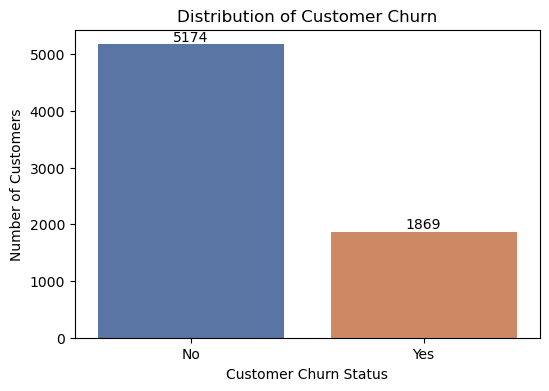

In [18]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x='Churn',
    hue='Churn',
    data=df,
    palette=['#4C72B0', '#DD8452'],
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Customer Churn')
plt.xlabel('Customer Churn Status')
plt.ylabel('Number of Customers')

plt.show()

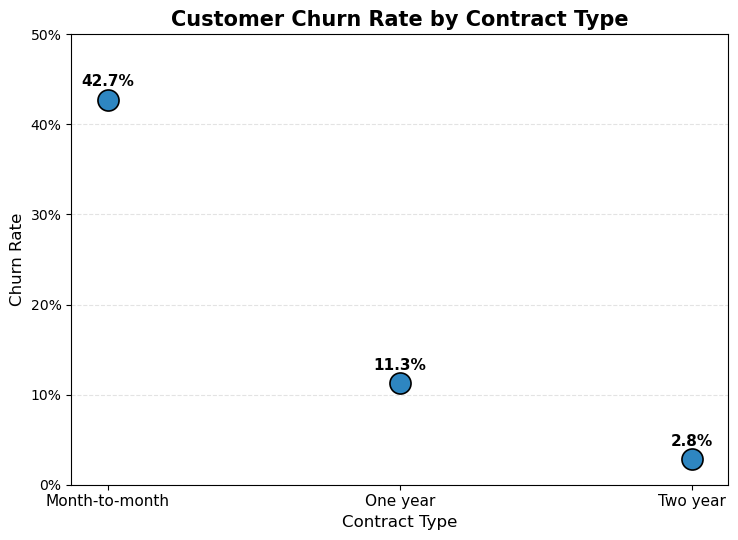

In [19]:
churn_rate = (
    df.groupby('Contract')['Churn']
      .apply(lambda x: (x == 'Yes').mean())
      .reset_index(name='ChurnRate')
)

plt.figure(figsize=(7.5,5.5))

x = [0.2, 1.0, 1.8]

plt.scatter(
    x,
    churn_rate['ChurnRate'],
    s=230,
    color='#2E86C1',
    edgecolors='black',
    linewidth=1.2,
    zorder=3
)

for xi, yi in zip(x, churn_rate['ChurnRate']):
    plt.text(
        xi,
        yi + 0.015,
        f'{yi:.1%}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.xticks(
    x,
    ['Month-to-month', 'One year', 'Two year'],
    fontsize=11
)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.ylim(0,0.5)
plt.xlim(0.1,1.9)

plt.title(
    'Customer Churn Rate by Contract Type',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Churn Rate', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.show()

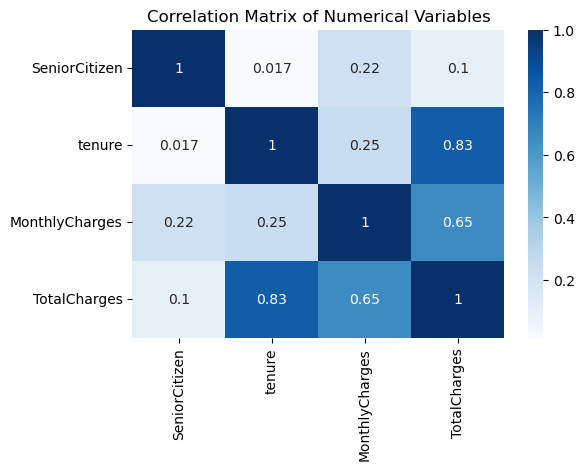

In [20]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(6,4))

sns.heatmap(corr,
            annot=True,
            cmap='Blues')

plt.title('Correlation Matrix of Numerical Variables')

plt.show()

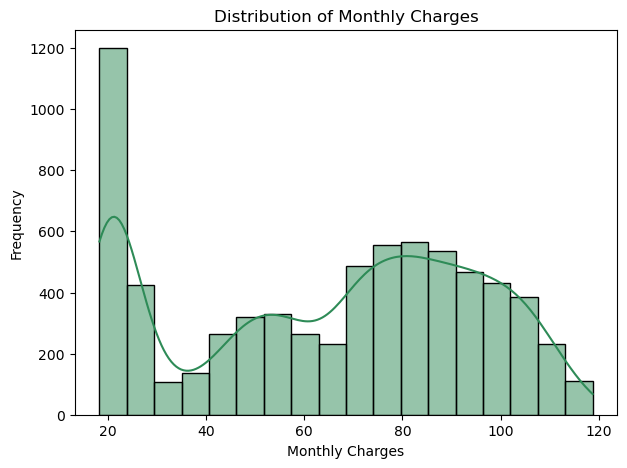

In [21]:
plt.figure(figsize=(7,5))

sns.histplot(
    df['MonthlyCharges'],
    kde=True,
    color='#2E8B57'      # Emerald Green
)

plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')

plt.show()

# 3.0 Data Preparation

In [22]:
import pandas as pd

# Load dataset
df = pd.read_csv('Telco_Cusomer_Churn.csv')

# Step 1: Identify and extract the target variable (Y)
y = df['Churn']

print("Target variable 'Churn' summary:")
print(y.value_counts())
print(f"\nTarget variable shape: {y.shape}")

Target variable 'Churn' summary:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Target variable shape: (7043,)


In [23]:
# Drop non-informative primary key identifier
df_clean = df.drop(columns=['customerID'])

# Verify updated dataset dimensions
print("Original Shape:", df.shape)
print("Updated Shape after dropping customerID:", df_clean.shape)

Original Shape: (7043, 21)
Updated Shape after dropping customerID: (7043, 20)


In [24]:
# Calculate number of duplicate rows and duplicate rate
duplicate_count = df.duplicated().sum()
duplicate_rate = (duplicate_count / len(df)) * 100

print(f"Duplicate Count: {duplicate_count}")
print(f"Duplicate Rate: {duplicate_rate:.2f}%")

Duplicate Count: 0
Duplicate Rate: 0.00%


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Telco_Cusomer_Churn.csv')

# Convert hidden blank values to NaN
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

# Count missing values
missing_totalcharges = df['TotalCharges'].isnull().sum()

print("Missing values in TotalCharges:",
      missing_totalcharges)

print("Missing rate:",
      missing_totalcharges / len(df) * 100)

Missing values in TotalCharges: 11
Missing rate: 0.1561834445548772


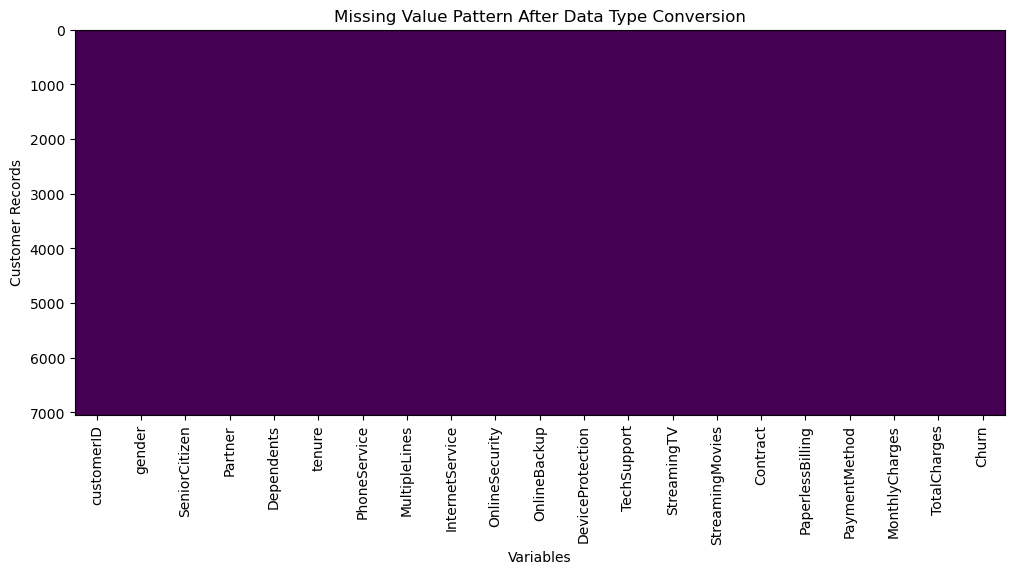

In [26]:
# Missing value heatmap
missing_matrix = df.isnull()

plt.figure(figsize=(12, 5))

plt.imshow(
    missing_matrix,
    aspect='auto',
    interpolation='none'
)

plt.title("Missing Value Pattern After Data Type Conversion")
plt.xlabel("Variables")
plt.ylabel("Customer Records")

plt.xticks(
    range(len(df.columns)),
    df.columns,
    rotation=90
)

plt.show()

In [27]:
# Identify records with missing TotalCharges
missing_records = df[df['TotalCharges'].isnull()]

# Examine relevant variables
print(
    missing_records[
        ['customerID', 'tenure',
         'MonthlyCharges', 'Contract',
         'TotalCharges', 'Churn']
    ]
)

      customerID  tenure  MonthlyCharges  Contract  TotalCharges Churn
488   4472-LVYGI       0           52.55  Two year           NaN    No
753   3115-CZMZD       0           20.25  Two year           NaN    No
936   5709-LVOEQ       0           80.85  Two year           NaN    No
1082  4367-NUYAO       0           25.75  Two year           NaN    No
1340  1371-DWPAZ       0           56.05  Two year           NaN    No
3331  7644-OMVMY       0           19.85  Two year           NaN    No
3826  3213-VVOLG       0           25.35  Two year           NaN    No
4380  2520-SGTTA       0           20.00  Two year           NaN    No
5218  2923-ARZLG       0           19.70  One year           NaN    No
6670  4075-WKNIU       0           73.35  Two year           NaN    No
6754  2775-SEFEE       0           61.90  Two year           NaN    No


In [28]:
print(
    missing_records['tenure'].value_counts()
)

print(
    missing_records['MonthlyCharges'].describe()
)

tenure
0    11
Name: count, dtype: int64
count    11.000000
mean     41.418182
std      23.831484
min      19.700000
25%      20.125000
50%      25.750000
75%      58.975000
max      80.850000
Name: MonthlyCharges, dtype: float64


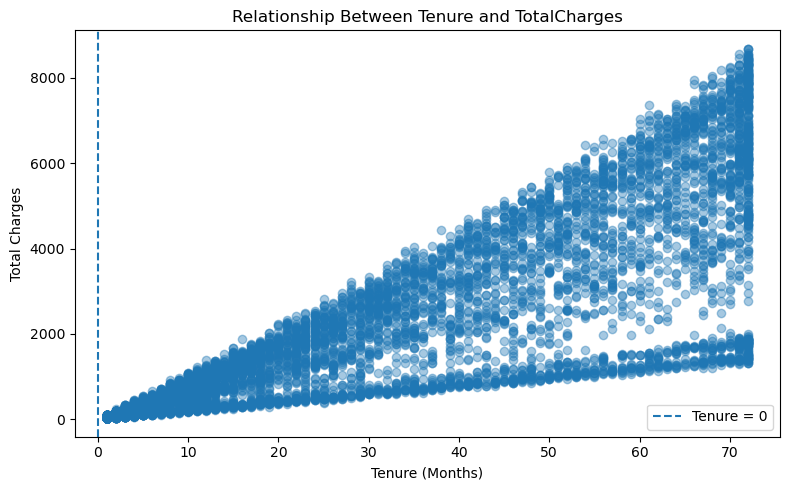

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert TotalCharges to numeric
df_plot = df.copy()

df_plot['TotalCharges'] = pd.to_numeric(
    df_plot['TotalCharges'],
    errors='coerce'
)

# Scatter plot
plt.figure(figsize=(8, 5))

plt.scatter(
    df_plot['tenure'],
    df_plot['TotalCharges'],
    alpha=0.4
)

plt.axvline(
    x=0,
    linestyle='--',
    label='Tenure = 0'
)

plt.xlabel('Tenure (Months)')
plt.ylabel('Total Charges')
plt.title('Relationship Between Tenure and TotalCharges')
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
# Replace missing TotalCharges with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# Verify the replacement
print(
    "Missing values after replacement:",
    df['TotalCharges'].isnull().sum()
)

print(
    "TotalCharges data type:",
    df['TotalCharges'].dtype
)

Missing values after replacement: 0
TotalCharges data type: float64


In [31]:
# Compare before and after
before = 11
after = df['TotalCharges'].isnull().sum()

print("Before replacement:", before)
print("After replacement:", after)

# Check all columns
print(df.isnull().sum())

Before replacement: 11
After replacement: 0
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


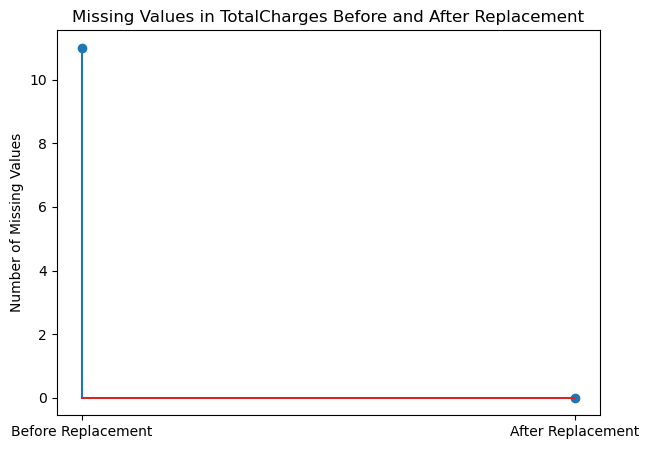

In [32]:
before = 11
after = 0

labels = ['Before Replacement', 'After Replacement']
values = [before, after]

plt.figure(figsize=(7, 5))

plt.stem(
    labels,
    values
)

plt.title(
    "Missing Values in TotalCharges Before and After Replacement"
)

plt.ylabel("Number of Missing Values")

plt.show()

In [33]:
from scipy.stats import chi2_contingency
import pandas as pd

# Identify categorical variables
categorical_cols = df.select_dtypes(
    include='object'
).columns.tolist()

# Remove target variable and customerID
categorical_cols = [
    col for col in categorical_cols
    if col not in ['Churn', 'customerID']
]

results = []

for col in categorical_cols:

    contingency_table = pd.crosstab(
        df[col],
        df['Churn']
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    results.append({
        'Variable': col,
        'Chi-Square': chi2,
        'p-value': p_value
    })

chi_square_results = pd.DataFrame(results)

chi_square_results = chi_square_results.sort_values(
    by='p-value'
)

print(
    chi_square_results.round(4)
)

            Variable  Chi-Square  p-value
12          Contract   1184.5966   0.0000
6     OnlineSecurity    849.9990   0.0000
9        TechSupport    828.1971   0.0000
5    InternetService    732.3096   0.0000
14     PaymentMethod    648.1423   0.0000
7       OnlineBackup    601.8128   0.0000
8   DeviceProtection    558.4194   0.0000
11   StreamingMovies    375.6615   0.0000
10       StreamingTV    374.2039   0.0000
13  PaperlessBilling    258.2776   0.0000
2         Dependents    189.1292   0.0000
1            Partner    158.7334   0.0000
4      MultipleLines     11.3304   0.0035
3       PhoneService      0.9150   0.3388
0             gender      0.4841   0.4866


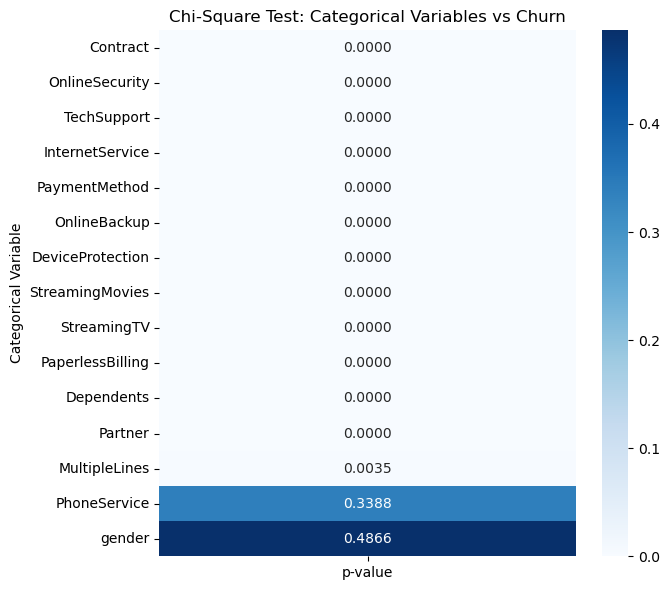

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = (
    chi_square_results
    .set_index('Variable')[['p-value']]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.4f',
    cmap='Blues'
)

plt.title(
    'Chi-Square Test: Categorical Variables vs Churn'
)

plt.xlabel('')
plt.ylabel('Categorical Variable')

plt.tight_layout()
plt.show()

In [35]:
# Create a copy before encoding
encoded_df = df.copy()

# Binary variables
binary_columns = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

# Binary mapping
for column in binary_columns:
    if column == 'gender':
        encoded_df[column] = encoded_df[column].map({
            'Female': 0,
            'Male': 1
        })
    else:
        encoded_df[column] = encoded_df[column].map({
            'No': 0,
            'Yes': 1
        })

print(encoded_df[binary_columns].head())

   gender  Partner  Dependents  PhoneService  PaperlessBilling  Churn
0       0        1           0             0                 1      0
1       1        0           0             1                 0      0
2       1        0           0             1                 1      1
3       1        0           0             0                 0      0
4       0        0           0             1                 1      1


In [36]:
comparison = pd.DataFrame({
    'Original Gender': ['Female', 'Male'],
    'Encoded Gender': [0, 1]
})

print(comparison)

  Original Gender  Encoded Gender
0          Female               0
1            Male               1


In [37]:
# Multi-class categorical variables
multi_class_columns = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

# Apply One-Hot Encoding
encoded_df = pd.get_dummies(
    encoded_df,
    columns=multi_class_columns,
    drop_first=True,
    dtype=int
)

print("Shape after encoding:", encoded_df.shape)

Shape after encoding: (7043, 32)


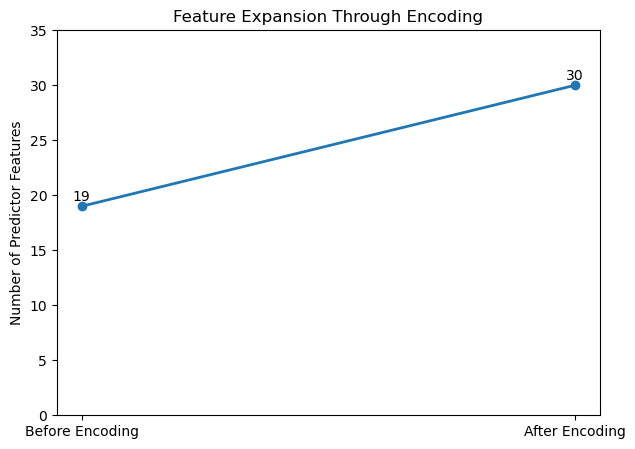

In [38]:
import matplotlib.pyplot as plt

stages = ['Before Encoding', 'After Encoding']
values = [19, 30]

plt.figure(figsize=(7, 5))

plt.plot(
    stages,
    values,
    marker='o',
    linewidth=2
)

# Add values above the points
for i, value in enumerate(values):
    plt.text(
        i,
        value + 0.5,
        str(value),
        ha='center'
    )

plt.title('Feature Expansion Through Encoding')
plt.ylabel('Number of Predictor Features')
plt.ylim(0, 35)

plt.show()

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Continuous numerical variables
continuous_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

# Calculate Q1 and Q3
Q1 = df[continuous_cols].quantile(0.25)
Q3 = df[continuous_cols].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate lower and upper boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create summary table
iqr_summary = pd.DataFrame({
    'Q1': Q1,
    'Q3': Q3,
    'IQR': IQR,
    'Lower Bound': lower_bound,
    'Upper Bound': upper_bound
})

print(iqr_summary.round(2))

                    Q1       Q3      IQR  Lower Bound  Upper Bound
tenure            9.00    55.00    46.00       -60.00       124.00
MonthlyCharges   35.50    89.85    54.35       -46.02       171.38
TotalCharges    398.55  3786.60  3388.05     -4683.52      8868.67


In [40]:
# Identify potential outliers
outlier_counts = {}

for column in continuous_cols:
    outliers = df[
        (df[column] < lower_bound[column]) |
        (df[column] > upper_bound[column])
    ]

    outlier_counts[column] = len(outliers)

print("Potential outliers:")
print(outlier_counts)

Potential outliers:
{'tenure': 0, 'MonthlyCharges': 0, 'TotalCharges': 0}


In [41]:
# Calculate outlier percentages
outlier_percentage = {}

for column in continuous_cols:
    count = outlier_counts[column]
    percentage = (count / len(df)) * 100

    outlier_percentage[column] = percentage

print("\nOutlier percentage:")
for column, percentage in outlier_percentage.items():
    print(f"{column}: {percentage:.2f}%")


Outlier percentage:
tenure: 0.00%
MonthlyCharges: 0.00%
TotalCharges: 0.00%


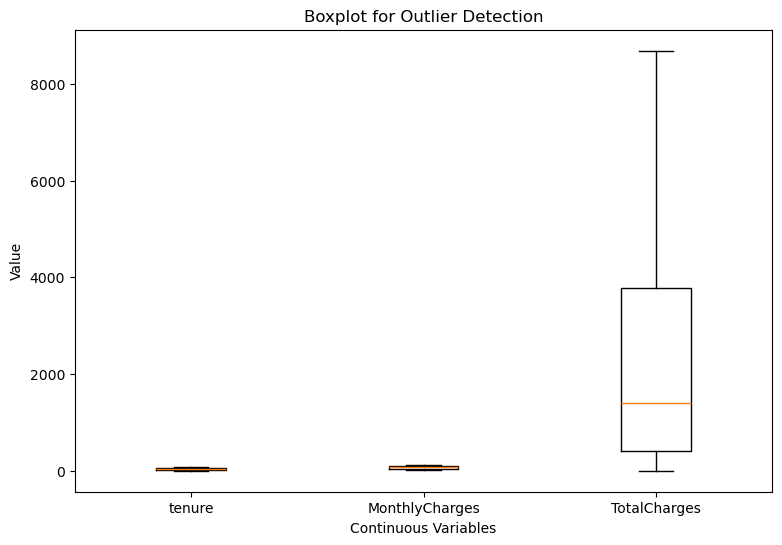

In [42]:
plt.figure(figsize=(9, 6))

plt.boxplot(
    [df[column] for column in continuous_cols],
    tick_labels=continuous_cols  # 将 labels 修改为 tick_labels
)

plt.title("Boxplot for Outlier Detection")
plt.xlabel("Continuous Variables")
plt.ylabel("Value")

plt.show()

In [43]:
# Display potential outlier records
for column in continuous_cols:

    outliers = df[
        (df[column] < lower_bound[column]) |
        (df[column] > upper_bound[column])
    ]

    print(f"\n{column}")
    print("Number of potential outliers:", len(outliers))

    if len(outliers) > 0:
        print(outliers[[column]].head())


tenure
Number of potential outliers: 0

MonthlyCharges
Number of potential outliers: 0

TotalCharges
Number of potential outliers: 0


In [44]:
outlier_summary = pd.DataFrame({
    'Variable': continuous_cols,
    'Potential Outliers': [
        outlier_counts[col] for col in continuous_cols
    ],
    'Percentage (%)': [
        outlier_percentage[col] for col in continuous_cols
    ]
})

outlier_summary['Percentage (%)'] = (
    outlier_summary['Percentage (%)'].round(2)
)

print(outlier_summary)

         Variable  Potential Outliers  Percentage (%)
0          tenure                   0             0.0
1  MonthlyCharges                   0             0.0
2    TotalCharges                   0             0.0


In [45]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load and clean TotalCharges before partitioning
df = pd.read_csv('Telco_Cusomer_Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', None), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# Separate predictors and target variable
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

# Stratified Data Partitioning (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (5634, 19)
Testing set shape: (1409, 19)


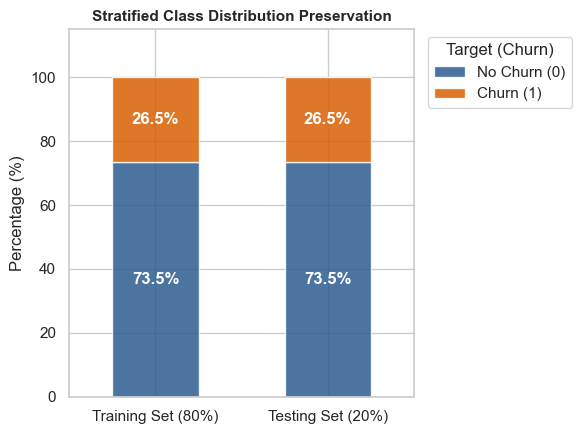

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

df = pd.read_csv('Telco_Cusomer_Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce').fillna(0.0)

X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

fig, ax = plt.subplots(figsize=(6, 4.5))
train_dist = y_train.value_counts(normalize=True) * 100
test_dist = y_test.value_counts(normalize=True) * 100

df_dist = pd.DataFrame({
    'No Churn (0)': [train_dist[0], test_dist[0]],
    'Churn (1)': [train_dist[1], test_dist[1]]
}, index=['Training Set (80%)', 'Testing Set (20%)'])

df_dist.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#2b5c8f', '#d95f02'],
    alpha=0.85
)

ax.set_title(
    'Stratified Class Distribution Preservation',
    fontsize=11,
    fontweight='bold'
)

ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, 115)

# Target (Churn) legend moved outside the graph
ax.legend(
    title='Target (Churn)',
    loc='upper left',
    bbox_to_anchor=(1.02, 1)
)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()

    if height > 0:
        x, y_pos = p.get_xy()

        ax.text(
            x + width/2,
            y_pos + height/2,
            f'{height:.1f}%',
            ha='center',
            va='center',
            color='white',
            fontweight='bold'
        )

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    'figure_3_20.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

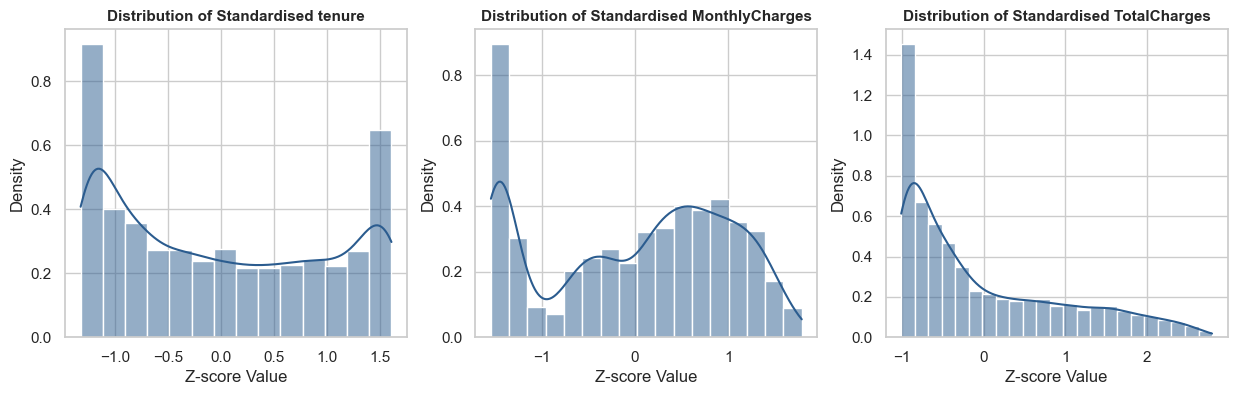

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

df = pd.read_csv('Telco_Cusomer_Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce').fillna(0.0)

X = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
y = df['Churn'].map({'Yes': 1, 'No': 0})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for i, col in enumerate(num_cols):
    sns.histplot(X_train_scaled[col], kde=True, ax=axes[i], color='#2b5c8f', stat="density")
    axes[i].set_title(f'Distribution of Standardised {col}', fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Z-score Value')
    axes[i].set_ylabel('Density')

plt.savefig('figure_3_20.png', dpi=300, bbox_inches='tight')
plt.show()

In [48]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Telco_Cusomer_Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce').fillna(0.0)

X = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
y = df['Churn'].map({'Yes': 1, 'No': 0})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
table_3_3_data = []

for col in num_cols:
    table_3_3_data.append({
        'Feature': col,
        'Mean (Before)': f"{X_train[col].mean():.2f}",
        'Std (Before)': f"{X_train[col].std():.2f}",
        'Mean (After)': f"{X_train_scaled[col].mean():.4f}",
        'Std (After)': f"{X_train_scaled[col].std():.4f}"
    })

df_table_3_3 = pd.DataFrame(table_3_3_data)

print(df_table_3_3.to_string(index=False))

df_table_3_3.to_csv('table_3_3_results.csv', index=False)

       Feature Mean (Before) Std (Before) Mean (After) Std (After)
        tenure         32.49        24.57      -0.0000      1.0001
MonthlyCharges         64.93        30.14      -0.0000      1.0001
  TotalCharges       2299.33      2279.20       0.0000      1.0001


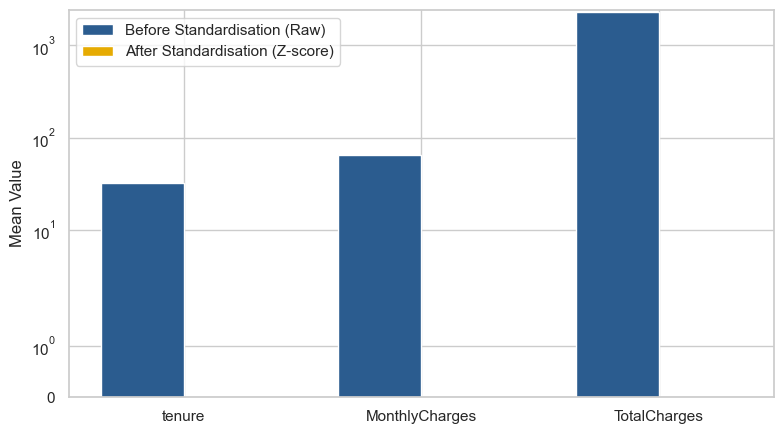

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

df = pd.read_csv('Telco_Cusomer_Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce').fillna(0.0)

X = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
y = df['Churn'].map({'Yes': 1, 'No': 0})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
means_before = [X_train[col].mean() for col in num_cols]
means_after = [X_train_scaled[col].mean() for col in num_cols]

fig, ax = plt.subplots(figsize=(8, 4.5))

x = np.arange(len(num_cols))
width = 0.35

rects1 = ax.bar(x - width/2, means_before, width, label='Before Standardisation (Raw)', color='#2b5c8f')
rects2 = ax.bar(x + width/2, means_after, width, label='After Standardisation (Z-score)', color='#e6ab02')

ax.set_ylabel('Mean Value')
ax.set_xticks(x)
ax.set_xticklabels(num_cols)
ax.legend()
ax.set_yscale('symlog')

plt.tight_layout()

plt.savefig('figure_3_21.png', dpi=300, bbox_inches='tight')
plt.show()

# 4.0 Data Modelling

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import pandas as pd
import numpy as np

In [51]:
df =pd.read_csv('Telco_Cusomer_Churn.csv')

#### Data Cleaning
#### Step 1: Duplicate check on the RAW dataset (Section 3.1.2)

In [52]:
print("Duplicate rows (raw data):", df.duplicated().sum())

Duplicate rows (raw data): 0


#### Step 2: Remove non-informative primary key

In [53]:
df_clean = df.drop(columns=['customerID'])
print("Shape after dropping customerID:", df_clean.shape)

Shape after dropping customerID: (7043, 20)


In [54]:
# Missing value handling
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# Replace the 11 missing values with 0.00 (all tenure = 0, per your report's justification)
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0.0)

print("Missing values remaining:", df_clean['TotalCharges'].isnull().sum())

Missing values remaining: 0


In [55]:
# Feature encoding
# Binary encoding for two-class categorical variables
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

df_clean['gender'] = df_clean['gender'].map({'Female': 1, 'Male': 0})
df_clean['Partner'] = df_clean['Partner'].map({'Yes': 1, 'No': 0})
df_clean['Dependents'] = df_clean['Dependents'].map({'Yes': 1, 'No': 0})
df_clean['PhoneService'] = df_clean['PhoneService'].map({'Yes': 1, 'No': 0})
df_clean['PaperlessBilling'] = df_clean['PaperlessBilling'].map({'Yes': 1, 'No': 0})
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

In [56]:
# One-Hot Encoding for multi-class categorical variables
multi_class_columns = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

encoded_df = pd.get_dummies(
    df_clean,
    columns=multi_class_columns,
    drop_first=True,
    dtype=int
)

print("Shape after encoding:", encoded_df.shape)

Shape after encoding: (7043, 31)


In [57]:
# Outlier detection (IQR)
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

Q1 = encoded_df[continuous_cols].quantile(0.25)
Q3 = encoded_df[continuous_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = {}
for col in continuous_cols:
    outliers = encoded_df[(encoded_df[col] < lower_bound[col]) | (encoded_df[col] > upper_bound[col])]
    outlier_counts[col] = len(outliers)

print("Potential outliers:", outlier_counts)

Potential outliers: {'tenure': 0, 'MonthlyCharges': 0, 'TotalCharges': 0}


In [58]:
# Data partitioning
X = encoded_df.drop(columns=['Churn'])
y = encoded_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Train shape: (5634, 30)
Test shape: (1409, 30)
Train churn rate: 0.2653532126375577
Test churn rate: 0.2654364797728886


In [59]:
# Feature scaling
scaler = StandardScaler()

# Fit ONLY on training data to prevent leakage
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("\nPreprocessing complete. Ready for modelling.")


Preprocessing complete. Ready for modelling.


In [60]:
# Shared results table — each model appends one row here (used for Table 4.1)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report
)
from sklearn.model_selection import GridSearchCV

results = []

def record_results(name, y_train, y_train_pred, y_test, y_test_pred, y_test_proba):
    """Compute metrics for one fitted model and append them to the shared results list."""
    results.append({
        "Model": name,
        "Accuracy (Train)": round(accuracy_score(y_train, y_train_pred) * 100, 2),
        "Accuracy (Test)": round(accuracy_score(y_test, y_test_pred) * 100, 2),
        "Precision (Test)": round(precision_score(y_test, y_test_pred) * 100, 2),
        "Recall (Test)": round(recall_score(y_test, y_test_pred) * 100, 2),
        "F1-Score (Test)": round(f1_score(y_test, y_test_pred) * 100, 2),
        "AUC (Test)": round(roc_auc_score(y_test, y_test_proba) * 100, 2)
    })

## 4.1 Logistic Regression (LR)

In [61]:
# Figure 4.1: The best parameter value of Logistic Regression
# 1. Choose model class
from sklearn.linear_model import LogisticRegression

# Hyperparameter search grid for Logistic Regression
# NOTE: the original grid capped C at 100, and GridSearchCV selected C=100 — the edge of the grid.
# This means the true optimum may lie beyond 100, so the grid is extended upward to confirm
# 100 is a genuine optimum and not an artefact of a grid that was too narrow.
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100, 200, 500, 1000],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

grid_search_lr = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_lr.fit(X_train, y_train)

print("Best parameters for Logistic Regression:", grid_search_lr.best_params_)
print("Best cross-validation accuracy:", grid_search_lr.best_score_ * 100)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters for Logistic Regression: {'C': 500, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validation accuracy: 80.52873045117344


In [62]:
# Figure 4.2: Top 5 parameter combinations by CV accuracy
# Show the full CV results so an edge-of-grid selection can be visually confirmed/rejected
cv_results_lr = pd.DataFrame(grid_search_lr.cv_results_)[['param_C', 'param_solver', 'mean_test_score']]
cv_results_lr = cv_results_lr.sort_values('mean_test_score', ascending=False)
print("\nTop 5 parameter combinations by CV accuracy:")
print(cv_results_lr.head())


Top 5 parameter combinations by CV accuracy:
    param_C param_solver  mean_test_score
12    500.0        lbfgs         0.805287
9     100.0    liblinear         0.805110
11    200.0    liblinear         0.805110
8     100.0        lbfgs         0.805109
14   1000.0        lbfgs         0.804932


In [63]:
# Figure 4.3: Logistic Regression results
# 2. & 3. Instantiate the FINAL model using the best parameters found above, and fit it
lr_model = grid_search_lr.best_estimator_
lr_model.fit(X_train, y_train)

# 4. Predict on training data (to check for overfitting) and on unseen test data
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)
y_test_proba_lr = lr_model.predict_proba(X_test)[:, 1]   # needed for AUC

record_results("Logistic Regression", y_train, y_train_pred_lr, y_test, y_test_pred_lr, y_test_proba_lr)

print("Logistic Regression Results")
print(f"Accuracy (Train) : {accuracy_score(y_train, y_train_pred_lr) *100 :.2f}%")
print(f"Accuracy (Test)  : {accuracy_score(y_test, y_test_pred_lr)*100 :.2f}%")
print(f"Precision        : {precision_score(y_test, y_test_pred_lr)*100 :.2f}%")
print(f"Recall           : {recall_score(y_test, y_test_pred_lr)*100 :.2f}%")
print(f"F1 Score         : {f1_score(y_test, y_test_pred_lr)*100 :.2f}%")
print(f"AUC              : {roc_auc_score(y_test, y_test_proba_lr)*100 :.2f}%")

Logistic Regression Results
Accuracy (Train) : 80.64%
Accuracy (Test)  : 80.06%
Precision        : 64.58%
Recall           : 55.08%
F1 Score         : 59.45%
AUC              : 84.09%


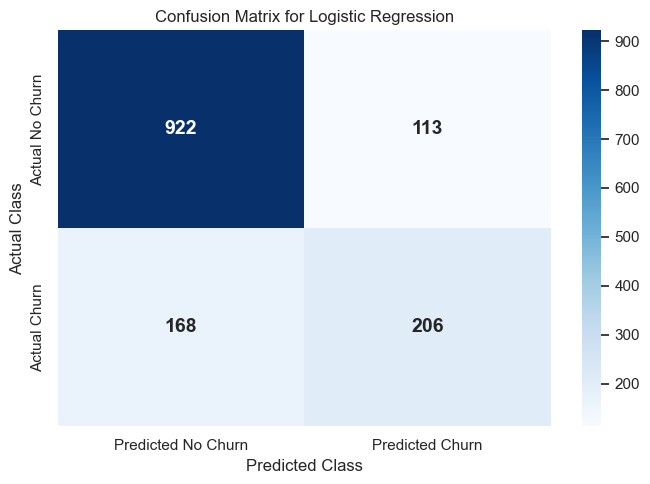

In [64]:
# Figure 4.4: Confusion Matrix for Logistic Regression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

cm = confusion_matrix(y_test, y_test_pred_lr)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted No Churn', 'Predicted Churn'],
    yticklabels=['Actual No Churn', 'Actual Churn'],
    annot_kws={'size': 14, 'weight': 'bold'}
)

plt.title('Confusion Matrix for Logistic Regression')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()

plt.savefig('lr_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

In [65]:
# Figure 4.5 Classification Report for Logistic Regression
print("Classification Report:")
print(classification_report(y_test, y_test_pred_lr, target_names=["No Churn", "Churn"]))

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



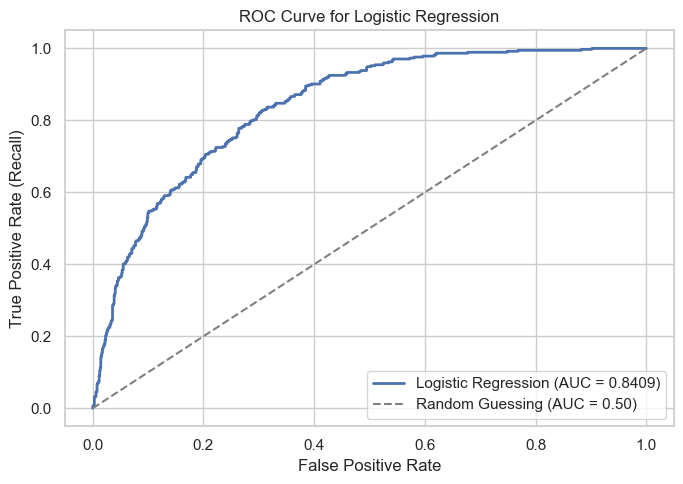

In [66]:
# Figure 4.6: ROC Curve for Logistic Regression
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba_lr)
auc_lr = roc_auc_score(y_test, y_test_proba_lr)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    color='#4C72B0',
    linewidth=2,
    label=f'Logistic Regression (AUC = {auc_lr:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    color='grey',
    linestyle='--',
    label='Random Guessing (AUC = 0.50)'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve for Logistic Regression')
plt.legend(loc='lower right')
plt.tight_layout()

plt.savefig('lr_roc_curve.png', dpi=200, bbox_inches='tight')
plt.show()

In [67]:
# Section 4.1.6: Feature Importance
# Feature coefficients — sorted by absolute magnitude, largest influence on churn (positive or negative) first
coefficients = pd.Series(lr_model.coef_[0], index=X_train.columns)
coef_sorted = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index)

print("Logistic Regression coefficients (sorted by absolute importance):")
print(coef_sorted.head(30))

Logistic Regression coefficients (sorted by absolute importance):
InternetService_Fiber optic              2.892753
MonthlyCharges                          -2.534276
MultipleLines_No phone service          -1.879134
Contract_Two year                       -1.378682
tenure                                  -1.309108
StreamingMovies_Yes                      1.056121
StreamingTV_Yes                          1.055845
PhoneService                            -0.778374
MultipleLines_Yes                        0.702333
Contract_One year                       -0.697802
TotalCharges                             0.587921
OnlineBackup_No internet service        -0.416476
DeviceProtection_No internet service    -0.416476
StreamingTV_No internet service         -0.416476
TechSupport_No internet service         -0.416476
InternetService_No                      -0.416476
OnlineSecurity_No internet service      -0.416476
StreamingMovies_No internet service     -0.416476
PaymentMethod_Electronic check    

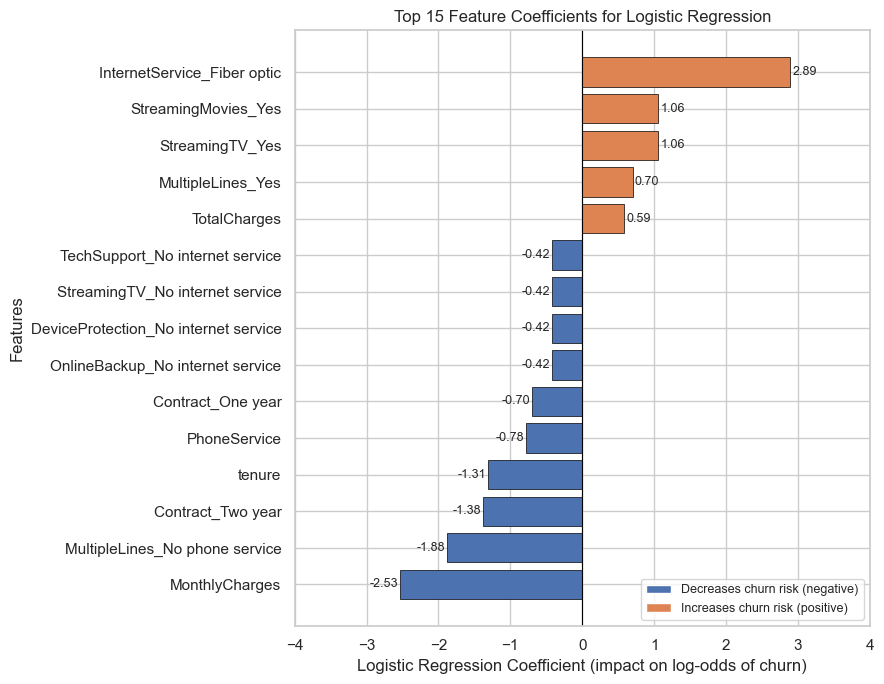

In [68]:
# Section 4.1.6: Feature Importance
# Figure 4.7: Top 15 Logistic Regression Coefficients
top_n = 15  # matches Table/Figure numbering used in the report
top_coefs = coef_sorted.head(top_n).sort_values()
colors = ['#4C72B0' if v < 0 else '#DD8452' for v in top_coefs.values]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top_coefs.index, top_coefs.values, color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression Coefficient (impact on log-odds of churn)')
ax.set_ylabel('Features')
ax.set_title(f'Top {top_n} Feature Coefficients for Logistic Regression')

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='#4C72B0', label='Decreases churn risk (negative)'),
                Patch(facecolor='#DD8452', label='Increases churn risk (positive)')]
ax.legend(handles=legend_elems, loc='lower right', fontsize=9)

ax.set_xlim(-4, 4)

for bar, v in zip(bars, top_coefs.values):
    x = v + (0.03 if v >= 0 else -0.03)
    ha = 'left' if v >= 0 else 'right'
    ax.text(x, bar.get_y() + bar.get_height()/2, f'{v:.2f}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.savefig('lr_feature_coefficients.png', dpi=200, bbox_inches='tight')
plt.show()

## 4.2 Random Forest (RF)

In [69]:
# 1. Choose model class
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter search grid for Random Forest (same style as Practical 5b)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_rf.fit(X_train, y_train)

print("Best parameters for Random Forest:", grid_search_rf.best_params_)
print("Best cross-validation accuracy:", grid_search_rf.best_score_ * 100)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters for Random Forest: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation accuracy: 80.17367978931475


In [70]:
# 2. & 3. Instantiate the FINAL model using the best parameters found above, and fit it
rf_model = grid_search_rf.best_estimator_
rf_model.fit(X_train, y_train)

# 4. Predict on training data and on unseen test data
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)
y_test_proba_rf = rf_model.predict_proba(X_test)[:, 1]

record_results("Random Forest", y_train, y_train_pred_rf, y_test, y_test_pred_rf, y_test_proba_rf)

print("===== Random Forest Results =====")
print(f"Accuracy (Train) : {accuracy_score(y_train, y_train_pred_rf):.4f}")
print(f"Accuracy (Test)  : {accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"Precision        : {precision_score(y_test, y_test_pred_rf):.4f}")
print(f"Recall           : {recall_score(y_test, y_test_pred_rf):.4f}")
print(f"F1 Score         : {f1_score(y_test, y_test_pred_rf):.4f}")
print(f"AUC              : {roc_auc_score(y_test, y_test_proba_rf):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_test_pred_rf, target_names=["No Churn", "Churn"]))

===== Random Forest Results =====
Accuracy (Train) : 0.8435
Accuracy (Test)  : 0.8055
Precision        : 0.6712
Recall           : 0.5241
F1 Score         : 0.5886
AUC              : 0.8438

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [71]:
# Figure 4.8: The Best Parameter Value of Random Forest

best_params_rf = grid_search_rf.best_params_

print("Best Parameters for Random Forest:")
for parameter, value in best_params_rf.items():
    print(f"{parameter}: {value}")

print(f"\nBest CV Accuracy: {grid_search_rf.best_score_:.4%}")

Best Parameters for Random Forest:
max_depth: 10
min_samples_leaf: 4
min_samples_split: 2
n_estimators: 200

Best CV Accuracy: 80.1737%


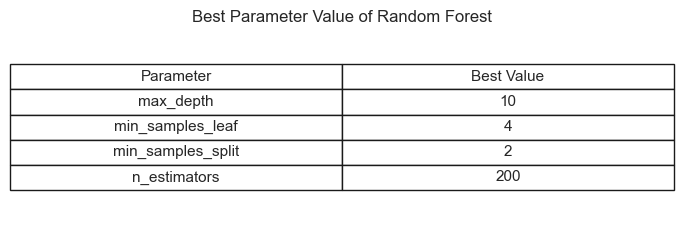

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

best_params_table = pd.DataFrame({
    "Parameter": list(grid_search_rf.best_params_.keys()),
    "Best Value": list(grid_search_rf.best_params_.values())
})

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.axis("off")

table = ax.table(
    cellText=best_params_table.values,
    colLabels=best_params_table.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)

plt.title("Best Parameter Value of Random Forest")
plt.tight_layout()
plt.show()

In [73]:
# Table 4.4: Random Forest Parameter Setting

rf_param_table = pd.DataFrame({
    "Parameter": [
        "n_estimators",
        "max_depth",
        "min_samples_split",
        "min_samples_leaf"
    ],
    "Values Searched": [
        "100, 200, 300",
        "None, 10, 20, 30",
        "2, 5, 10",
        "1, 2, 4"
    ],
    "Best Value": [
        grid_search_rf.best_params_["n_estimators"],
        grid_search_rf.best_params_["max_depth"],
        grid_search_rf.best_params_["min_samples_split"],
        grid_search_rf.best_params_["min_samples_leaf"]
    ]
})

display(rf_param_table)

,Parameter,Values Searched,Best Value
0,n_estimators,"100, 200, 300",200
1,max_depth,"None, 10, 20, 30",10
2,min_samples_split,"2, 5, 10",2
3,min_samples_leaf,"1, 2, 4",4


In [74]:
# Figure 4.9: Top 5 Parameter Combinations by CV Accuracy

cv_results_rf = pd.DataFrame(grid_search_rf.cv_results_)

top5_rf = cv_results_rf[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "mean_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(5)

top5_rf_display = top5_rf.copy()

top5_rf_display["mean_test_score"] = (
    top5_rf_display["mean_test_score"] * 100
).round(2)

top5_rf_display.columns = [
    "n_estimators",
    "max_depth",
    "min_samples_split",
    "min_samples_leaf",
    "CV Accuracy (%)",
    "Rank"
]

display(top5_rf_display)

,n_estimators,max_depth,min_samples_split,min_samples_leaf,CV Accuracy (%),Rank
46,200,10,2,4,80.17,1
49,200,10,5,4,80.17,1
48,100,10,5,4,80.12,3
45,100,10,2,4,80.12,3
36,100,10,2,2,80.00,5


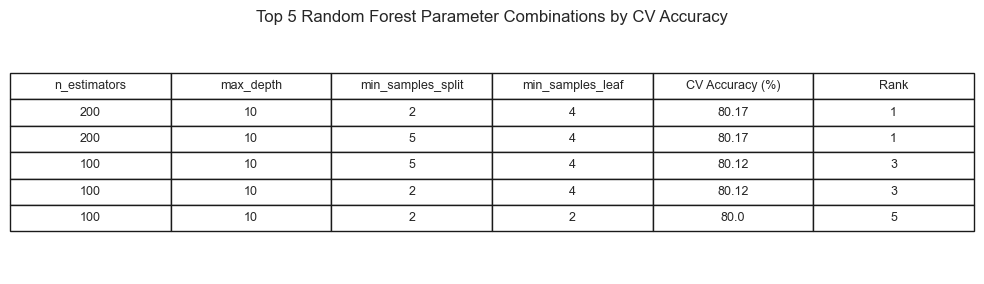

In [75]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")

table = ax.table(
    cellText=top5_rf_display.values,
    colLabels=top5_rf_display.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

plt.title("Top 5 Random Forest Parameter Combinations by CV Accuracy")
plt.tight_layout()
plt.show()

In [76]:
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

rf_train_accuracy = accuracy_score(
    y_train,
    y_train_pred_rf
)

rf_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_rf
)

accuracy_rf_table = pd.DataFrame({
    "Dataset": [
        "Training Data",
        "Test Data"
    ],
    "Accuracy (%)": [
        rf_train_accuracy * 100,
        rf_test_accuracy * 100
    ]
})

display(accuracy_rf_table)

,Dataset,Accuracy (%)
0,Training Data,84.345048
1,Test Data,80.553584


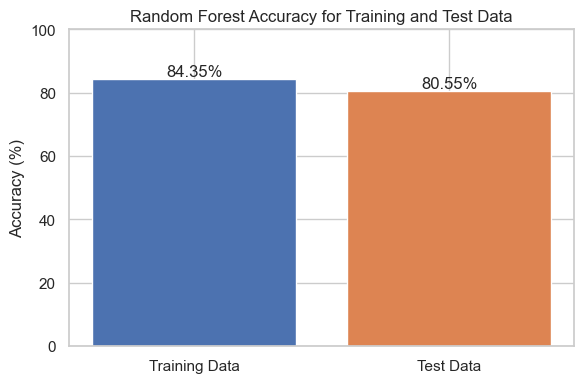

In [77]:
import matplotlib.pyplot as plt
import pandas as pd

accuracy_rf_table = pd.DataFrame({
    "Dataset": ["Training Data", "Test Data"],
    "Accuracy (%)": [84.35, 80.55]
})

fig, ax = plt.subplots(figsize=(6, 4))

colors = ["#4C72B0", "#DD8452"]

bars = ax.bar(
    accuracy_rf_table["Dataset"],
    accuracy_rf_table["Accuracy (%)"],
    color=colors
)

ax.set_ylabel("Accuracy (%)")
ax.set_title("Random Forest Accuracy for Training and Test Data")
ax.set_ylim(0, 100)

for bar, value in zip(bars, accuracy_rf_table["Accuracy (%)"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [78]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(
    y_test,
    y_test_pred_rf
)

cm_rf_table = pd.DataFrame(
    cm_rf,
    index=["Actual No Churn", "Actual Churn"],
    columns=["Predicted No Churn", "Predicted Churn"]
)

display(cm_rf_table)

,Predicted No Churn,Predicted Churn
Actual No Churn,939,96
Actual Churn,178,196


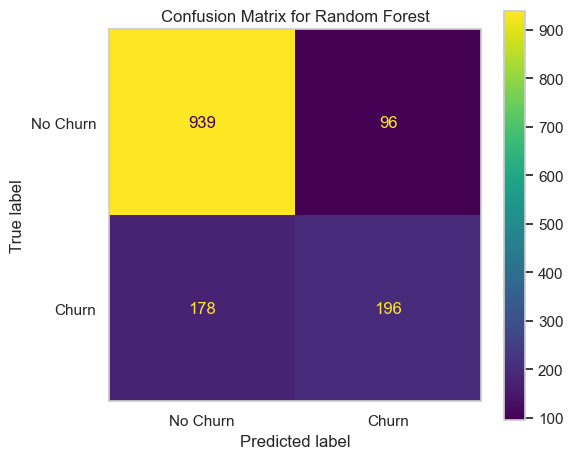

In [79]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Churn", "Churn"]
)

disp.plot(
    ax=ax,
    values_format="d"
)

ax.grid(False)

ax.set_title("Confusion Matrix for Random Forest")

plt.tight_layout()
plt.show()

In [80]:
from sklearn.metrics import classification_report

rf_report = classification_report(
    y_test,
    y_test_pred_rf,
    target_names=["No Churn", "Churn"],
    output_dict=True
)

rf_report_table = pd.DataFrame(
    rf_report
).transpose()

rf_report_table = rf_report_table.round(2)

display(rf_report_table)

,precision,recall,f1-score,support
No Churn,0.84,0.91,0.87,1035.00
Churn,0.67,0.52,0.59,374.00
accuracy,0.81,0.81,0.81,0.81
macro avg,0.76,0.72,0.73,1409.00
weighted avg,0.80,0.81,0.80,1409.00


In [81]:
print("Classification Report for Random Forest\n")

print(
    classification_report(
        y_test,
        y_test_pred_rf,
        target_names=["No Churn", "Churn"]
    )
)

Classification Report for Random Forest

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



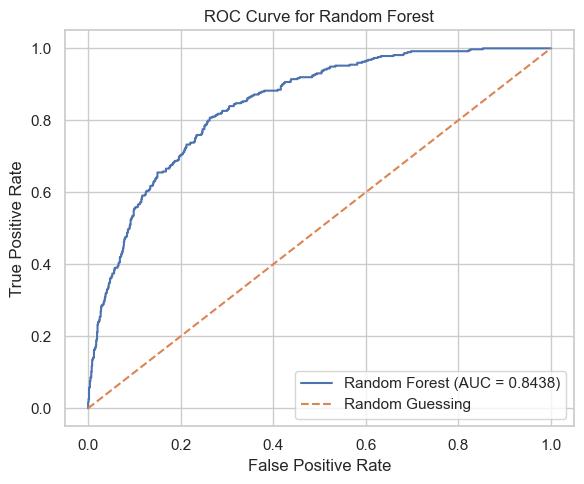

In [82]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test,
    y_test_proba_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_test_proba_rf
)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.4f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guessing"
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve for Random Forest")

ax.legend()

plt.tight_layout()
plt.show()

In [83]:
# Random Forest Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from the trained Random Forest model
importance = rf_model.feature_importances_

# Create DataFrame
feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

# Sort by importance
feature_importance_rf = feature_importance_rf.sort_values(
    by='Importance',
    ascending=False
)

# Select top 15 features
top15_rf = feature_importance_rf.head(15)

# Display the Top 15 features
print("Top 15 Feature Importance:")
display(top15_rf)

Top 15 Feature Importance:


,Feature,Importance
4,tenure,0.196193
8,TotalCharges,0.156893
7,MonthlyCharges,0.108470
11,InternetService_Fiber optic,0.075879
28,PaymentMethod_Electronic check,0.065686
26,Contract_Two year,0.062328
25,Contract_One year,0.035077
14,OnlineSecurity_Yes,0.034012
20,TechSupport_Yes,0.029398
6,PaperlessBilling,0.022087


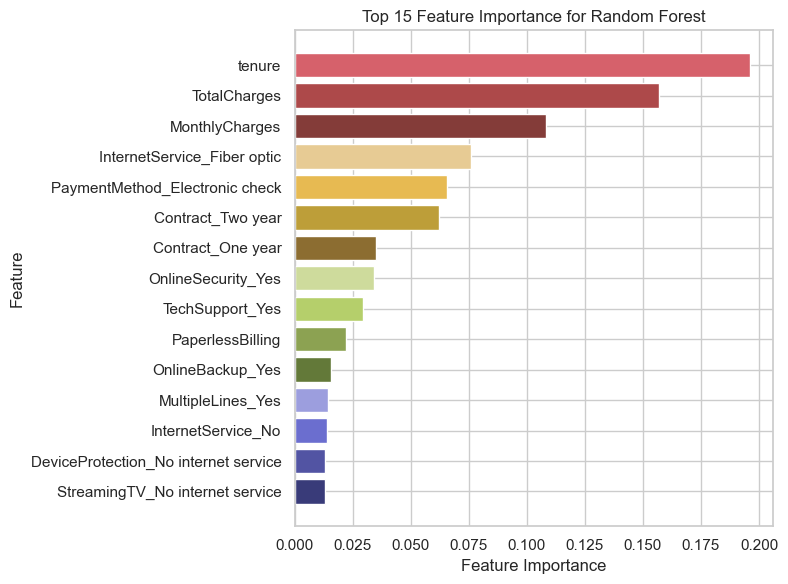

In [84]:
# Figure 4.14: Top 15 Feature Importance for Random Forest

plt.figure(figsize=(8, 6))

colors = plt.cm.tab20b(range(15))

plt.barh(
    top15_rf['Feature'][::-1],
    top15_rf['Importance'][::-1],
    color=colors
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance for Random Forest")

plt.tight_layout()
plt.show()

## 4.3 Support Vector Machine (SVM)

In [85]:
# 1. Choose model class
from sklearn.svm import SVC

# Hyperparameter search grid for SVM (same style as Practical 5b)
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_search_svm = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_svm.fit(X_train, y_train)

print("Best parameters for SVM:", grid_search_svm.best_params_)
print("Best cross-validation accuracy:", grid_search_svm.best_score_ * 100)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters for SVM: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best cross-validation accuracy: 80.54655548218207


In [86]:
# 2. & 3. Instantiate the FINAL model using the best parameters found above, and fit it
svm_model = grid_search_svm.best_estimator_
svm_model.fit(X_train, y_train)

# 4. Predict on training data and on unseen test data
y_train_pred_svm = svm_model.predict(X_train)
y_test_pred_svm = svm_model.predict(X_test)
y_test_proba_svm = svm_model.predict_proba(X_test)[:, 1]

record_results("SVM", y_train, y_train_pred_svm, y_test, y_test_pred_svm, y_test_proba_svm)

print("===== SVM Results =====")
print(f"Accuracy (Train) : {accuracy_score(y_train, y_train_pred_svm):.4f}")
print(f"Accuracy (Test)  : {accuracy_score(y_test, y_test_pred_svm):.4f}")
print(f"Precision        : {precision_score(y_test, y_test_pred_svm):.4f}")
print(f"Recall           : {recall_score(y_test, y_test_pred_svm):.4f}")
print(f"F1 Score         : {f1_score(y_test, y_test_pred_svm):.4f}")
print(f"AUC              : {roc_auc_score(y_test, y_test_proba_svm):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_test_pred_svm, target_names=["No Churn", "Churn"]))

===== SVM Results =====
Accuracy (Train) : 0.8161
Accuracy (Test)  : 0.7935
Precision        : 0.6487
Recall           : 0.4840
F1 Score         : 0.5544
AUC              : 0.7990

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.65      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [87]:
# Figure 4.15: Best Parameter Value of SVM

best_params_svm = grid_search_svm.best_params_

print("Best Parameters for SVM:")

for parameter, value in best_params_svm.items():
    print(f"{parameter}: {value}")

print(f"\nBest CV Accuracy: {grid_search_svm.best_score_:.4f}")

Best Parameters for SVM:
C: 10
gamma: auto
kernel: rbf

Best CV Accuracy: 0.8055


In [88]:
# Table 4.16: SVM Parameter Setting

svm_param_table = pd.DataFrame({
    "Parameter": [
        "C",
        "kernel",
        "gamma"
    ],
    "Values Searched": [
        "0.1, 1, 10, 100",
        "linear, rbf",
        "scale, auto"
    ],
    "Best Value": [
        grid_search_svm.best_params_["C"],
        grid_search_svm.best_params_["kernel"],
        grid_search_svm.best_params_["gamma"]
    ]
})

display(svm_param_table)

,Parameter,Values Searched,Best Value
0,C,"0.1, 1, 10, 100",10
1,kernel,"linear, rbf",rbf
2,gamma,"scale, auto",auto


In [89]:
# Figure 4.17: Top 5 Parameter Combinations by CV Accuracy

cv_results_svm = pd.DataFrame(
    grid_search_svm.cv_results_
)

top5_svm = cv_results_svm[
    [
        'param_C',
        'param_kernel',
        'param_gamma',
        'mean_test_score',
        'rank_test_score'
    ]
].sort_values(
    by='mean_test_score',
    ascending=False
).head(5)

top5_svm_display = top5_svm.copy()

top5_svm_display['mean_test_score'] = (
    top5_svm_display['mean_test_score'] * 100
).round(2)

top5_svm_display.columns = [
    'C',
    'Kernel',
    'Gamma',
    'CV Accuracy (%)',
    'Rank'
]

display(top5_svm_display)

,C,Kernel,Gamma,CV Accuracy (%),Rank
11,10.0,rbf,auto,80.55,1
5,1.0,rbf,scale,80.30,2
15,100.0,rbf,auto,80.10,3
7,1.0,rbf,auto,80.03,4
0,0.1,linear,scale,80.01,5


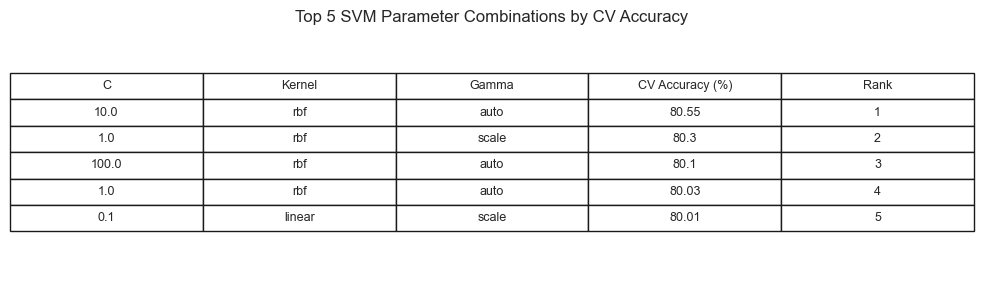

In [90]:
# Figure 4.18: Top 5 SVM Parameter Combinations by CV Accuracy

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))

ax.axis('off')

table = ax.table(
    cellText=top5_svm_display.values,
    colLabels=top5_svm_display.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

plt.title('Top 5 SVM Parameter Combinations by CV Accuracy')
plt.tight_layout()

plt.show()

In [91]:
# Final SVM model using the best parameters

svm_model = grid_search_svm.best_estimator_

svm_model.fit(X_train, y_train)

y_train_pred_svm = svm_model.predict(X_train)
y_test_pred_svm = svm_model.predict(X_test)
y_test_proba_svm = svm_model.predict_proba(X_test)[:, 1]

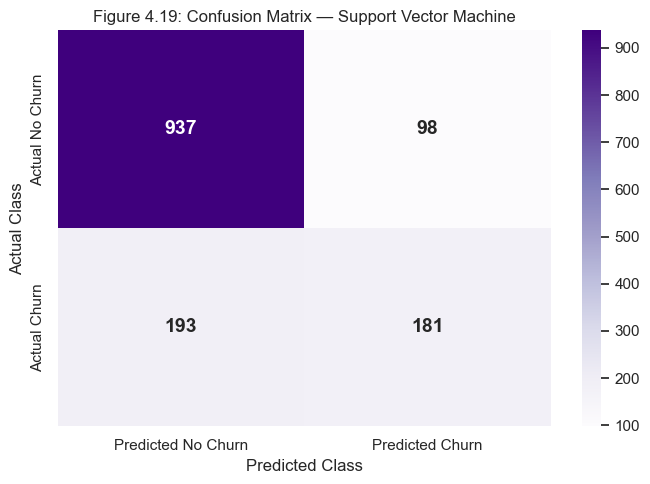

In [92]:
# Figure 4.19: Confusion Matrix for Support Vector Machine

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_svm = confusion_matrix(y_test, y_test_pred_svm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Predicted No Churn', 'Predicted Churn'],
    yticklabels=['Actual No Churn', 'Actual Churn'],
    annot_kws={'size': 14, 'weight': 'bold'}
)

plt.title('Figure 4.19: Confusion Matrix — Support Vector Machine')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()

plt.show()

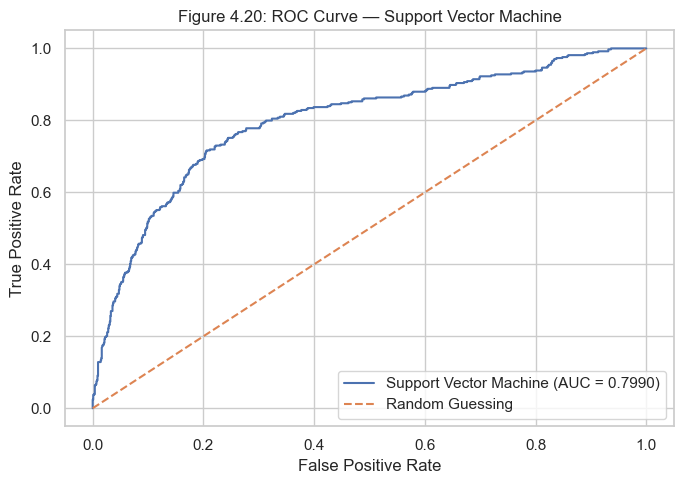

In [93]:
# Figure 4.20: ROC Curve for Support Vector Machine

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr_svm, tpr_svm, thresholds_svm = roc_curve(
    y_test,
    y_test_proba_svm
)

svm_auc = roc_auc_score(
    y_test,
    y_test_proba_svm
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f'Support Vector Machine (AUC = {svm_auc:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Guessing'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 4.20: ROC Curve — Support Vector Machine')
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

In [94]:
# SVM Permutation Importance

from sklearn.inspection import permutation_importance

perm_importance_svm = permutation_importance(
    svm_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

svm_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_importance_svm.importances_mean
})

svm_importance = svm_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Top 15 Feature Importance for SVM:")
display(svm_importance.head(15))

Top 15 Feature Importance for SVM:


,Feature,Importance
11,InternetService_Fiber optic,0.030802
4,tenure,0.027040
8,TotalCharges,0.016749
7,MonthlyCharges,0.014265
10,MultipleLines_Yes,0.004258
6,PaperlessBilling,0.002910
14,OnlineSecurity_Yes,0.002910
28,PaymentMethod_Electronic check,0.002626
24,StreamingMovies_Yes,0.002555
26,Contract_Two year,0.002413


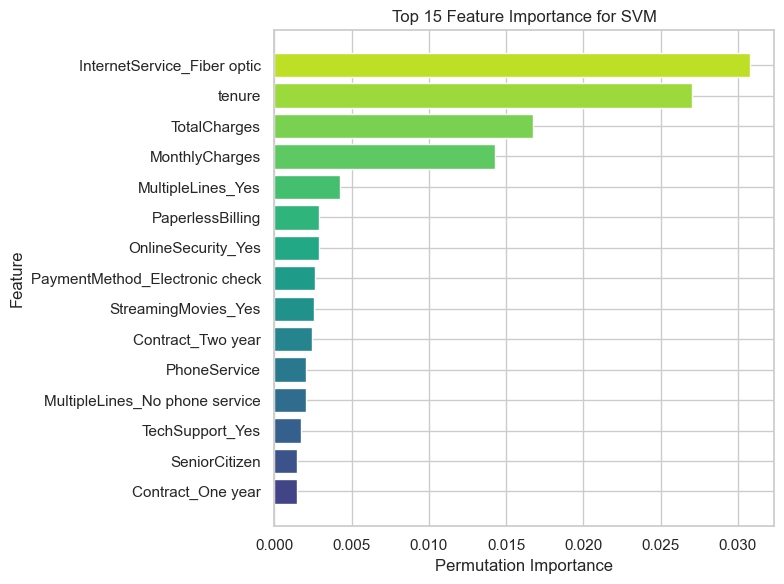

In [95]:
# Figure 4.21: Top 15 Feature Importance for SVM

top_n = 15
top15_svm = svm_importance.head(top_n).sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(8, 6))

# Create gradient colours
colors = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(top15_svm))
)

plt.barh(
    top15_svm['Feature'],
    top15_svm['Importance'],
    color=colors
)

plt.xlabel('Permutation Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importance for SVM')

plt.tight_layout()
plt.show()

# 5.0 Evaluation

### Table 5.1: Comparative Results of LR, RF and SVM

#### Final performance comparison of LR, RF and S

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

#### Calculate final test metrics

In [97]:
evaluation_results = []

In [98]:
models = {
    "Logistic Regression": (
        y_train_pred_lr,
        y_test_pred_lr,
        y_test_proba_lr
    ),
    "Random Forest": (
        y_train_pred_rf,
        y_test_pred_rf,
        y_test_proba_rf
    ),
    "Support Vector Machine": (
        y_train_pred_svm,
        y_test_pred_svm,
        y_test_proba_svm
    )
}

In [99]:
for model_name, (train_pred, test_pred, test_proba) in models.items():

    evaluation_results.append({
        "Model": model_name,
        "Training Accuracy (%)":
            accuracy_score(y_train, train_pred) * 100,

        "Test Accuracy (%)":
            accuracy_score(y_test, test_pred) * 100,

        "Precision (%)":
            precision_score(y_test, test_pred) * 100,

        "Recall (%)":
            recall_score(y_test, test_pred) * 100,

        "F1-score (%)":
            f1_score(y_test, test_pred) * 100,

        "AUC (%)":
            roc_auc_score(y_test, test_proba) * 100
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df = evaluation_df.round(2)

display(evaluation_df)

,Model,Training Accuracy (%),Test Accuracy (%),Precision (%),Recall (%),F1-score (%),AUC (%)
0,Logistic Regression,80.64,80.06,64.58,55.08,59.45,84.09
1,Random Forest,84.35,80.55,67.12,52.41,58.86,84.38
2,Support Vector Machine,81.61,79.35,64.87,48.40,55.44,79.90


#### Comparison table

In [100]:
comparison_table = evaluation_df.copy()

In [101]:
comparison_table.columns = [
    "Model",
    "Training Accuracy",
    "Test Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "AUC"
]

In [102]:
for column in comparison_table.columns[1:]:
    comparison_table[column] = (
        comparison_table[column].map(lambda x: f"{x:.2f}%")
    )

In [103]:
display(comparison_table)

,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,80.64%,80.06%,64.58%,55.08%,59.45%,84.09%
1,Random Forest,84.35%,80.55%,67.12%,52.41%,58.86%,84.38%
2,Support Vector Machine,81.61%,79.35%,64.87%,48.40%,55.44%,79.90%


#### Identify the best model for each metrics

In [104]:
# Best model by evaluation metric
numeric_results = evaluation_df.set_index("Model")

In [105]:
best_models = {
    "Test Accuracy": numeric_results["Test Accuracy (%)"].idxmax(),
    "Precision": numeric_results["Precision (%)"].idxmax(),
    "Recall": numeric_results["Recall (%)"].idxmax(),
    "F1-score": numeric_results["F1-score (%)"].idxmax(),
    "AUC": numeric_results["AUC (%)"].idxmax()
}

In [106]:
print("Best Model for Each Evaluation Metric")
print("-" * 50)
for metric, model in best_models.items():
    value = numeric_results.loc[model, metric + " (%)"]
    print(f"{metric:<20}: {model} ({value:.2f}%)")

Best Model for Each Evaluation Metric
--------------------------------------------------
Test Accuracy       : Random Forest (80.55%)
Precision           : Random Forest (67.12%)
Recall              : Logistic Regression (55.08%)
F1-score            : Logistic Regression (59.45%)
AUC                 : Random Forest (84.38%)


#### Training Accuracy Comparison

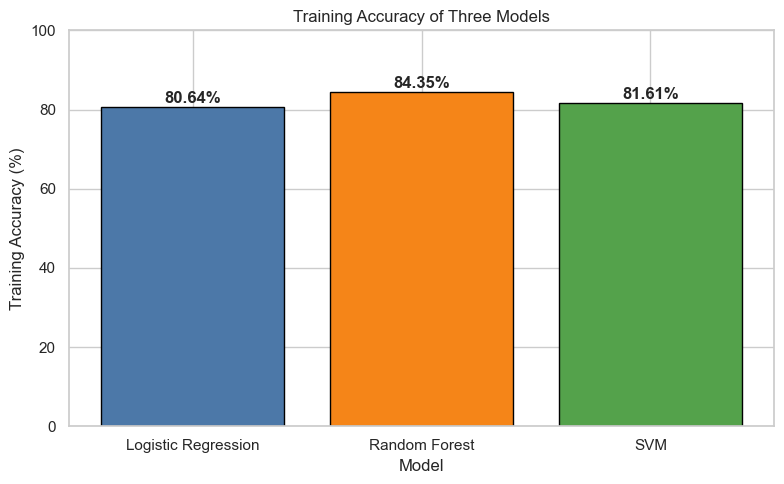

In [122]:
# Display results
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Calculate training accuracy for all three models
training_accuracy_lr = accuracy_score(y_train, y_train_pred_lr) * 100
training_accuracy_rf = accuracy_score(y_train, y_train_pred_rf) * 100
training_accuracy_svm = accuracy_score(y_train, y_train_pred_svm) * 100

# Store model names and training accuracy
models = [
    'Logistic Regression',
    'Random Forest',
    'SVM'
]

training_accuracy = [
    training_accuracy_lr,
    training_accuracy_rf,
    training_accuracy_svm
]

# Create one graph
plt.figure(figsize=(8, 5))

bars = plt.bar(
    models,
    training_accuracy,
    color=['#4C78A8', '#F58518', '#54A24B'],
    edgecolor='black'
)

plt.title('Training Accuracy of Three Models')
plt.xlabel('Model')
plt.ylabel('Training Accuracy (%)')
plt.ylim(0, 100)

# Display accuracy values on top of each bar
for bar, value in zip(bars, training_accuracy):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f'{value:.2f}%',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

#### Test Accuracy Comparison

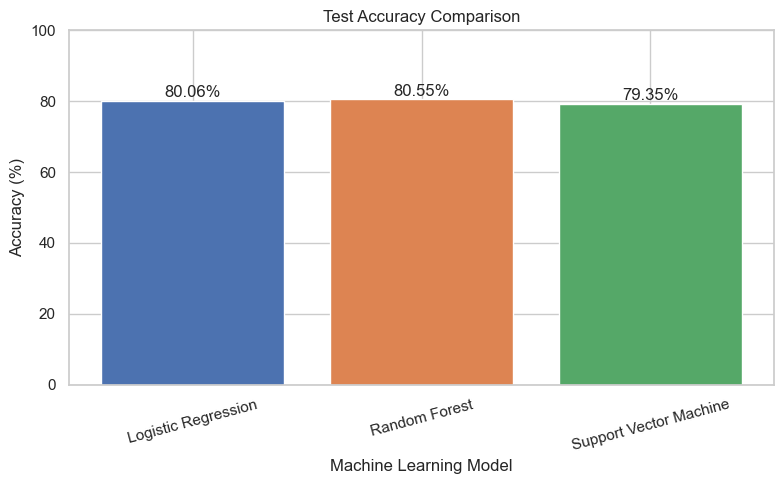

In [107]:
plt.figure(figsize=(8, 5))

models_names = evaluation_df["Model"]
test_accuracy = evaluation_df["Test Accuracy (%)"]

colors = ['#4C72B0', '#DD8452', '#55A868']

bars = plt.bar(models_names, test_accuracy, color=colors)

plt.title("Test Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, test_accuracy):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Precision Comparison

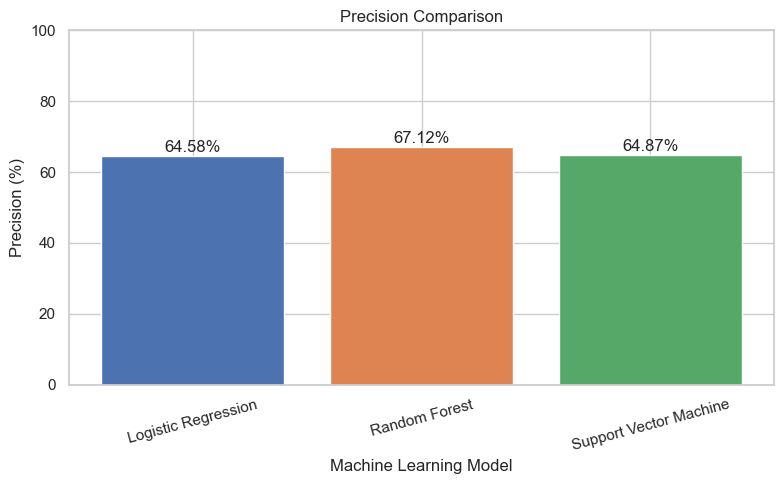

In [108]:
plt.figure(figsize=(8, 5))

precision_values = evaluation_df["Precision (%)"]

colors = ['#4C72B0', '#DD8452', '#55A868']

bars = plt.bar(models_names, precision_values, color=colors)

plt.title("Precision Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Precision (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, precision_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Recall

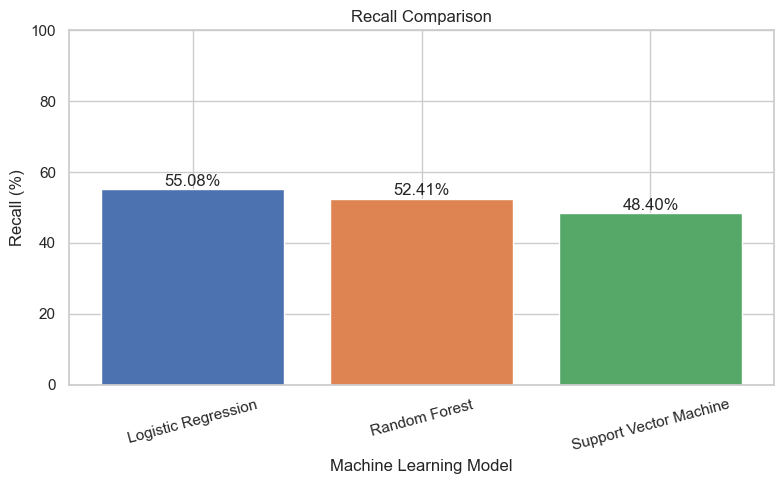

In [109]:
plt.figure(figsize=(8, 5))

recall_values = evaluation_df["Recall (%)"]

colors = ['#4C72B0', '#DD8452', '#55A868']

bars = plt.bar(models_names, recall_values, color=colors)

plt.title("Recall Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Recall (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, recall_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### F1-score comparison

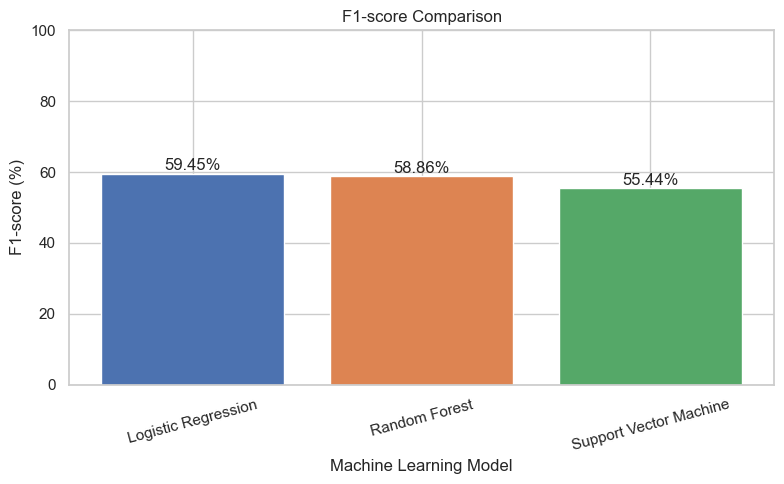

In [110]:
plt.figure(figsize=(8, 5))

f1_values = evaluation_df["F1-score (%)"]

colors = ['#4C72B0', '#DD8452', '#55A868']

bars = plt.bar(models_names, f1_values, color=colors)

plt.title("F1-score Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("F1-score (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, f1_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### AUC comparison

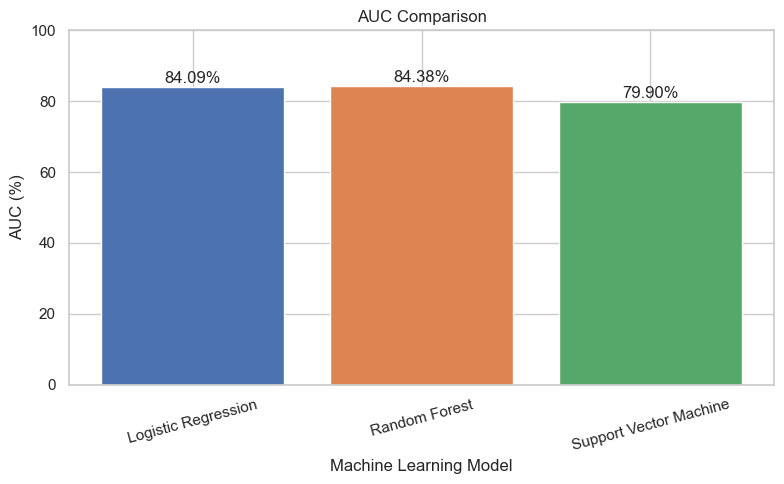

In [111]:
plt.figure(figsize=(8, 5))

auc_values = evaluation_df["AUC (%)"]

colors = ['#4C72B0', '#DD8452', '#55A868']

bars = plt.bar(models_names, auc_values, color=colors)

plt.title("AUC Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("AUC (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, auc_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Overall model performance comparison

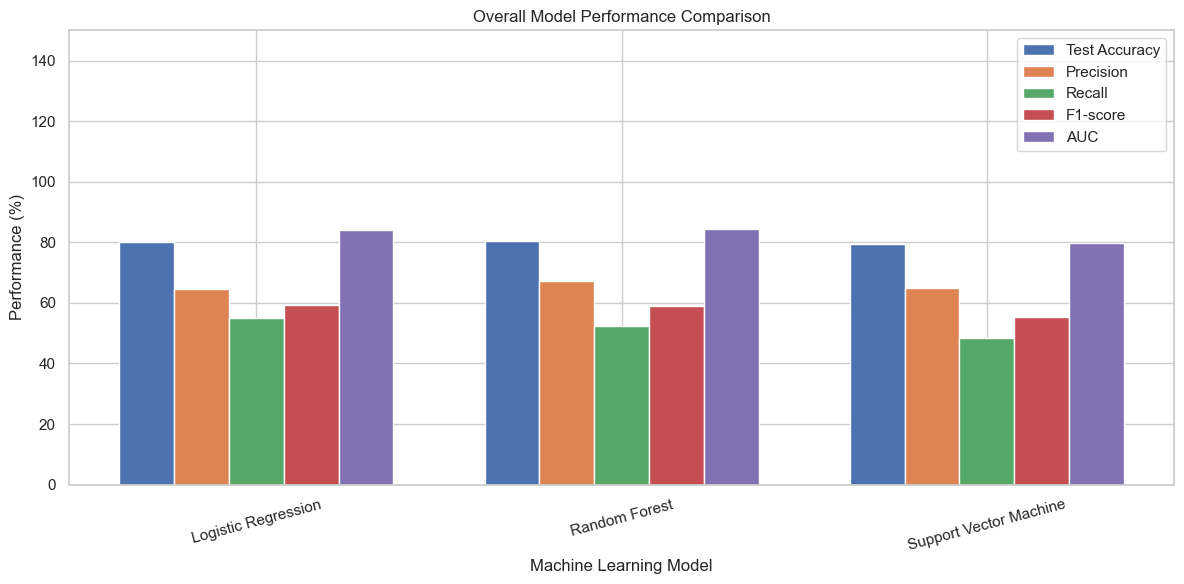

In [112]:
metrics = [
    "Test Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-score (%)",
    "AUC (%)"
]

x = np.arange(len(models_names))
width = 0.15

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):

    values = evaluation_df[metric]

    plt.bar(
        x + (i - 2) * width,
        values,
        width,
        label=metric.replace(" (%)", "")
    )

plt.xticks(x, models_names, rotation=15)
plt.ylabel("Performance (%)")
plt.xlabel("Machine Learning Model")
plt.title("Overall Model Performance Comparison")
plt.ylim(0, 150)

plt.legend()
plt.tight_layout()
plt.show()

#### Training and test accuracy

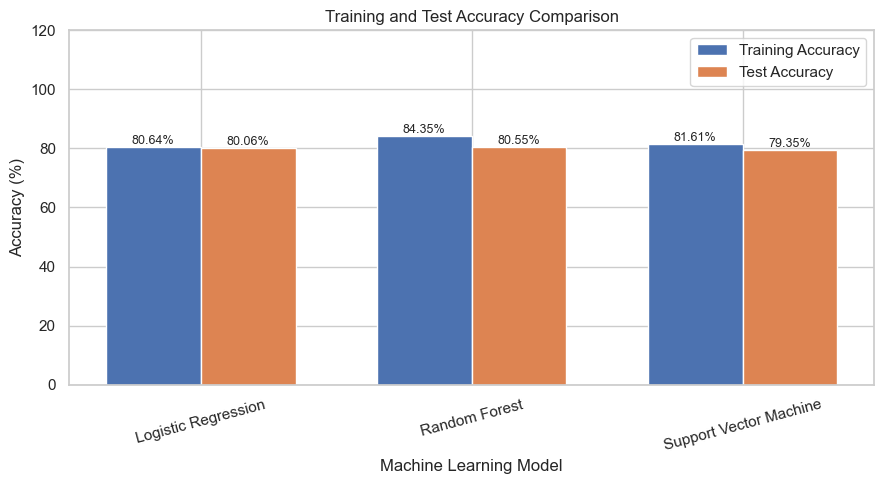

In [113]:
x = np.arange(len(evaluation_df))
width = 0.35

plt.figure(figsize=(9, 5))

train_values = evaluation_df["Training Accuracy (%)"]
test_values = evaluation_df["Test Accuracy (%)"]

bars1 = plt.bar(
    x - width / 2,
    train_values,
    width,
    label="Training Accuracy"
)

bars2 = plt.bar(
    x + width / 2,
    test_values,
    width,
    label="Test Accuracy"
)

plt.xticks(x, evaluation_df["Model"], rotation=15)
plt.ylabel("Accuracy (%)")
plt.xlabel("Machine Learning Model")
plt.title("Training and Test Accuracy Comparison")
plt.ylim(0, 120)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{bar.get_height():.2f}%",
            ha="center",
            fontsize=9
        )

plt.legend()
plt.tight_layout()
plt.show()

#### Model ranking

In [114]:
ranking_df = evaluation_df.copy()

ranking_df["Average Score (%)"] = (
    ranking_df[
        [
            "Test Accuracy (%)",
            "Precision (%)",
            "Recall (%)",
            "F1-score (%)",
            "AUC (%)"
        ]
    ].mean(axis=1)
)

ranking_df = ranking_df.sort_values(
    by="Average Score (%)",
    ascending=False
).reset_index(drop=True)

ranking_df.insert(
    0,
    "Rank",
    range(1, len(ranking_df) + 1)
)

display(ranking_df.round(2))

,Rank,Model,Training Accuracy (%),Test Accuracy (%),Precision (%),Recall (%),F1-score (%),AUC (%),Average Score (%)
0,1,Random Forest,84.35,80.55,67.12,52.41,58.86,84.38,68.66
1,2,Logistic Regression,80.64,80.06,64.58,55.08,59.45,84.09,68.65
2,3,Support Vector Machine,81.61,79.35,64.87,48.40,55.44,79.90,65.59


#### Best Model

In [115]:
best_model = ranking_df.loc[0, "Model"]

print("-" * 70)
print("FINAL MODEL EVALUATION")
print("-" * 70)

print(f"\nRecommended model: {best_model}")

for _, row in ranking_df.iterrows():

    print(f"\n{row['Model']}")
    print(f"  Test Accuracy : {row['Test Accuracy (%)']:.2f}%")
    print(f"  Precision     : {row['Precision (%)']:.2f}%")
    print(f"  Recall        : {row['Recall (%)']:.2f}%")
    print(f"  F1-score      : {row['F1-score (%)']:.2f}%")
    print(f"  AUC           : {row['AUC (%)']:.2f}%")

----------------------------------------------------------------------
FINAL MODEL EVALUATION
----------------------------------------------------------------------

Recommended model: Random Forest

Random Forest
  Test Accuracy : 80.55%
  Precision     : 67.12%
  Recall        : 52.41%
  F1-score      : 58.86%
  AUC           : 84.38%

Logistic Regression
  Test Accuracy : 80.06%
  Precision     : 64.58%
  Recall        : 55.08%
  F1-score      : 59.45%
  AUC           : 84.09%

Support Vector Machine
  Test Accuracy : 79.35%
  Precision     : 64.87%
  Recall        : 48.40%
  F1-score      : 55.44%
  AUC           : 79.90%


#### Model Deployment

In [116]:
import joblib

# Save the final trained model/pipeline
joblib.dump(best_model, "churn_model.pkl")

print("Model saved successfully as churn_model.pkl")

Model saved successfully as churn_model.pkl
